In [1]:
import pandas as pd


In [2]:
pd.read_csv("/content/General_information_schisoprenia.csv")

,donor_id,age,average_age,most_likely_sex,diagnoses
0,NND 10-WXX,51-55,53,F,"Psychiatric Disorders, Schizophrenia"
1,NND 16-XIT,66-70,68,M,"Psychiatric Disorders, Schizophrenia"
2,NND 51-OPX,66-70,68,M,"Psychiatric Disorders, Schizophrenia"
3,NND 59-RQG,61-65,63,F,"Psychiatric Disorders, Schizophrenia"
4,NND 64-EUI,66-70,68,F,"Psychiatric Disorders, Schizophrenia"
5,NND 67-POX,56-60,58,M,"Psychiatric Disorders, Schizophrenia"
6,NND 68-QAU,51-55,53,F,"Psychiatric Disorders, Schizophrenia"
7,NND 69-RLW,66-70,68,M,"Psychiatric Disorders, Schizophrenia"
8,NND 81-PQC,66-70,68,M,"Psychiatric Disorders, Schizophrenia"
9,NND 82-QLY,61-65,63,M,"Psychiatric Disorders, Schizophrenia"


In [3]:
df = pd.read_csv("/content/General_information_schisoprenia.csv")
display(df.head())

,donor_id,age,average_age,most_likely_sex,diagnoses
0,NND 10-WXX,51-55,53,F,"Psychiatric Disorders, Schizophrenia"
1,NND 16-XIT,66-70,68,M,"Psychiatric Disorders, Schizophrenia"
2,NND 51-OPX,66-70,68,M,"Psychiatric Disorders, Schizophrenia"
3,NND 59-RQG,61-65,63,F,"Psychiatric Disorders, Schizophrenia"
4,NND 64-EUI,66-70,68,F,"Psychiatric Disorders, Schizophrenia"


In [4]:
df[['min_age', 'max_age']] = df['age'].str.split('-', expand=True)
df['min_age'] = pd.to_numeric(df['min_age'])
df['max_age'] = pd.to_numeric(df['max_age'])
display(df.head())

,donor_id,age,average_age,most_likely_sex,diagnoses,min_age,max_age
0,NND 10-WXX,51-55,53,F,"Psychiatric Disorders, Schizophrenia",51,55
1,NND 16-XIT,66-70,68,M,"Psychiatric Disorders, Schizophrenia",66,70
2,NND 51-OPX,66-70,68,M,"Psychiatric Disorders, Schizophrenia",66,70
3,NND 59-RQG,61-65,63,F,"Psychiatric Disorders, Schizophrenia",61,65
4,NND 64-EUI,66-70,68,F,"Psychiatric Disorders, Schizophrenia",66,70


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sns.set_style('whitegrid')

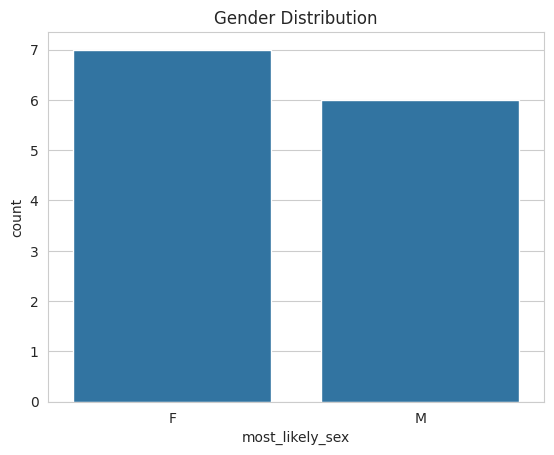

In [7]:
sns.countplot(x='most_likely_sex', data=df)
plt.title('Gender Distribution')
plt.show()

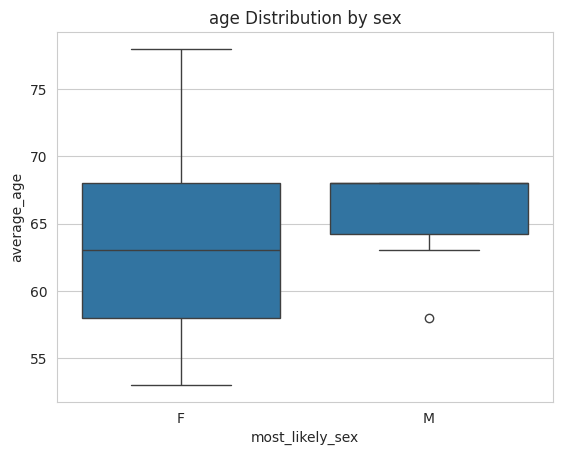

In [8]:
sns.boxplot(x='most_likely_sex', data=df, y='average_age')
plt.title('age Distribution by sex')
plt.show()

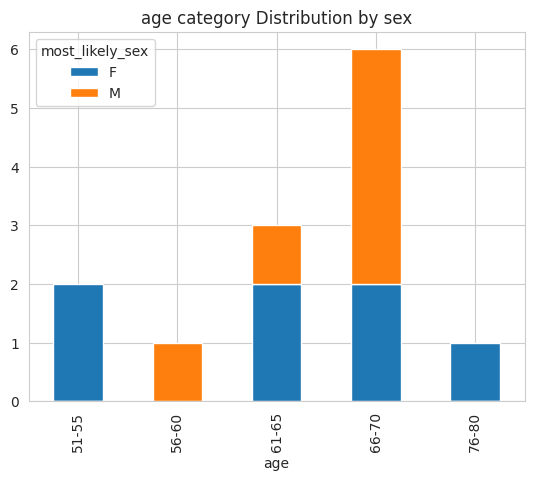

In [9]:
pd.crosstab (df['age'], df['most_likely_sex']).plot(kind='bar', stacked=True)
plt.title('age category Distribution by sex')
plt.show()

quality check for data

In [10]:
print(f"duplicate id: {df.duplicated(subset=['donor_id']).sum()}")

duplicate id: 0


In [11]:
z_score =(df['average_age']-df['average_age'].mean())/df['average_age'].std()
print(z_score)

0    -1.675307
1     0.502592
2     0.502592
3    -0.223374
4     0.502592
5    -0.949341
6    -1.675307
7     0.502592
8     0.502592
9    -0.223374
10    1.954525
11    0.502592
12   -0.223374
Name: average_age, dtype: float64


In [12]:
older_than_75 = df[df['average_age'] > 75]
print(older_than_75)

      donor_id    age  average_age most_likely_sex  \
10  NND 89-RDZ  76-80           78               F   

                               diagnoses  min_age  max_age  
10  Psychiatric Disorders, Schizophrenia       76       80  


In [13]:
import numpy as np


resampling

In [14]:
import numpy as np

means = []
for _ in range(10000):
    bootstrap_sample = df['average_age'].sample(n=len(df), replace=True)
    means.append(bootstrap_sample.mean())

# Get 95% confidence interval
ci_lower = np.percentile(means, 2.5)
ci_upper = np.percentile(means, 97.5)

print(f"Mean age: {df['average_age'].mean():.1f}")
print(f"95% CI from bootstrap: [{ci_lower:.1f}, {ci_upper:.1f}]")

Mean age: 64.5
95% CI from bootstrap: [60.7, 68.0]


merge other data (first creating a fake genomic data)


In [16]:
# Create fake genomic data for each donor
num_donors = len(df)
genomic_data = pd.DataFrame({
    'donor_id': df['donor_id'],
    'gene_A_expression': np.random.rand(num_donors),
    'gene_B_expression': np.random.rand(num_donors),
    'gene_C_expression': np.random.rand(num_donors)
})
display(genomic_data.head())

,donor_id,gene_A_expression,gene_B_expression,gene_C_expression
0,NND 10-WXX,0.124205,0.595529,0.009445
1,NND 16-XIT,0.621583,0.173509,0.969565
2,NND 51-OPX,0.799274,0.918840,0.400585
3,NND 59-RQG,0.532491,0.326461,0.971078
4,NND 64-EUI,0.716368,0.666668,0.900116


In [18]:
df_merged = pd.merge(df, genomic_data, on='donor_id', how='left')
display(df_merged.head())

,donor_id,age,average_age,most_likely_sex,diagnoses,min_age,max_age,gene_A_expression,gene_B_expression,gene_C_expression
0,NND 10-WXX,51-55,53,F,"Psychiatric Disorders, Schizophrenia",51,55,0.124205,0.595529,0.009445
1,NND 16-XIT,66-70,68,M,"Psychiatric Disorders, Schizophrenia",66,70,0.621583,0.173509,0.969565
2,NND 51-OPX,66-70,68,M,"Psychiatric Disorders, Schizophrenia",66,70,0.799274,0.918840,0.400585
3,NND 59-RQG,61-65,63,F,"Psychiatric Disorders, Schizophrenia",61,65,0.532491,0.326461,0.971078
4,NND 64-EUI,66-70,68,F,"Psychiatric Disorders, Schizophrenia",66,70,0.716368,0.666668,0.900116


In [19]:
mean_gene_expression_by_diagnosis = df_merged.groupby('diagnoses')[['gene_A_expression', 'gene_B_expression', 'gene_C_expression']].mean()
display(mean_gene_expression_by_diagnosis)

,gene_A_expression,gene_B_expression,gene_C_expression
diagnoses,,,
"Psychiatric Disorders, Schizophrenia",0.556281,0.606514,0.54925


### Correlation Analysis(not ideal for any visualisation)

In [20]:
correlation_gene_age = df_merged[['gene_A_expression', 'gene_B_expression', 'gene_C_expression', 'average_age']].corr()['average_age']
display(correlation_gene_age)

,average_age
gene_A_expression,0.187644
gene_B_expression,-0.142641
gene_C_expression,0.388247
average_age,1.000000


### Scatter Plot: Gene C Expression vs. Average Age(for testing)

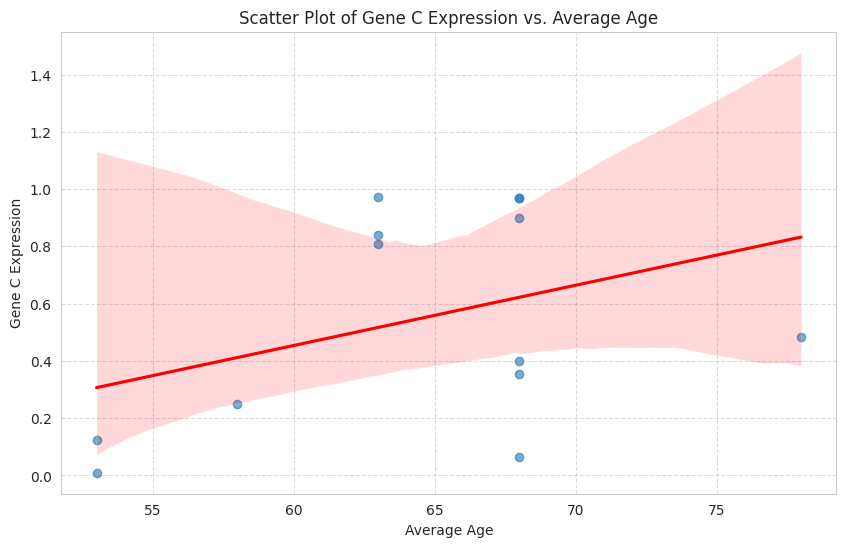

In [23]:
plt.figure(figsize=(10, 6))
sns.regplot(x='average_age', y='gene_C_expression', data=df_merged, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Scatter Plot of Gene C Expression vs. Average Age')
plt.xlabel('Average Age')
plt.ylabel('Gene C Expression')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pairplot of Gene Expressions

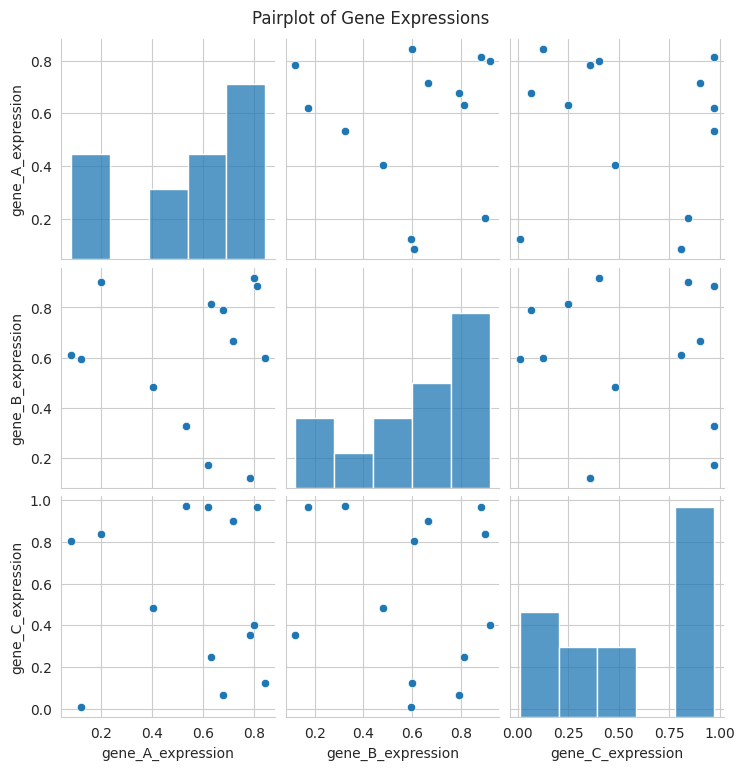

In [24]:
sns.pairplot(df_merged[['gene_A_expression', 'gene_B_expression', 'gene_C_expression']])
plt.suptitle('Pairplot of Gene Expressions', y=1.02) # Adjust suptitle position
plt.show()